In [68]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint, adfuller

In [69]:
# 如果 yfinance 下载出现 rate limit error，修改代理设置，并运行以下代码
# 详情见 https://blog.csdn.net/m0_50837851/article/details/146198595

import os
proxy = 'http://127.0.0.1:7897'	# 代理设置，此处修改
os.environ['HTTP_PROXY'] = proxy 
os.environ['HTTPS_PROXY'] = proxy 


In [70]:
def load_prices(symbols, start="2021-01-01", end=None, log_price=False):
    data = yf.download(symbols, start=start, end=end, auto_adjust=True, progress=False)["Close"].dropna()
    return np.log(data) if log_price else data


def fit_spread(y, x, add_const=True):
    X = sm.add_constant(x) if add_const else x
    res = sm.OLS(y, X).fit()
    beta = res.params.iloc[-1]               # slope on x
    alpha = res.params.iloc[0] if add_const else 0.0
    z = res.resid if add_const else (y - beta * x)
    return res, beta, alpha, z


def ou_halflife(z):
    prevz = z.shift(1)
    dz = (z - prevz).dropna()
    prevz = prevz.loc[dz.index]
    theta = sm.OLS(dz, (prevz - prevz.mean())).fit().params.iloc[0]
    halflife = np.inf if theta >= 0 else -np.log(2) / theta
    return theta, halflife, dz


def run_tests(y, x, z, alpha=0.05):
    coint_t, coint_p, coint_crit = coint(y, x)
    adf_stat, adf_p, adf_lags, adf_nobs, adf_crit, adf_icbest = adfuller(z.dropna(), autolag="AIC")
    verdict = {
        "coint_msg": "LIKELY COINTEGRATED" if coint_p < alpha else "NOT COINTEGRATED at 5%",
        "adf_msg": "STATIONARY (reject unit root at 5%)" if adf_p < alpha else "NON-STATIONARY at 5%",
    }
    return {
        "coint_t": coint_t,
        "coint_p": coint_p,
        "coint_crit": coint_crit,
        "adf_stat": adf_stat,
        "adf_p": adf_p,
        "adf_lags": adf_lags,
        "adf_nobs": adf_nobs,
        "adf_crit": adf_crit,
        "adf_icbest": adf_icbest,
        **verdict,
    }


def plot_spread(z, dz, halflife):
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(z.index, z.values, label="z (spread = residual)")
    axes[0].axhline(z.mean(), color="red", linestyle="--", label="mean(z)")
    hl_txt = f"{halflife:.2f}" if np.isfinite(halflife) else "INF"
    axes[0].set_title(f"Spread z (residual). Half-life ≈ {hl_txt} days")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(dz.index, dz.values, label="dz = z(t) - z(t-1)")
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("dz")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


hedge_ratio = 1.331609  | alpha = -3.954994
theta = -2.294640e-02 | half-life = 30.21 days
--- Engle-Granger ---
t-stat = -3.8529, p = 0.0115 -> LIKELY COINTEGRATED
--- ADF on spread z ---
ADF stat = -3.8502, p = 0.0024, lags = 3, nobs = 999 -> STATIONARY (reject unit root at 5%)


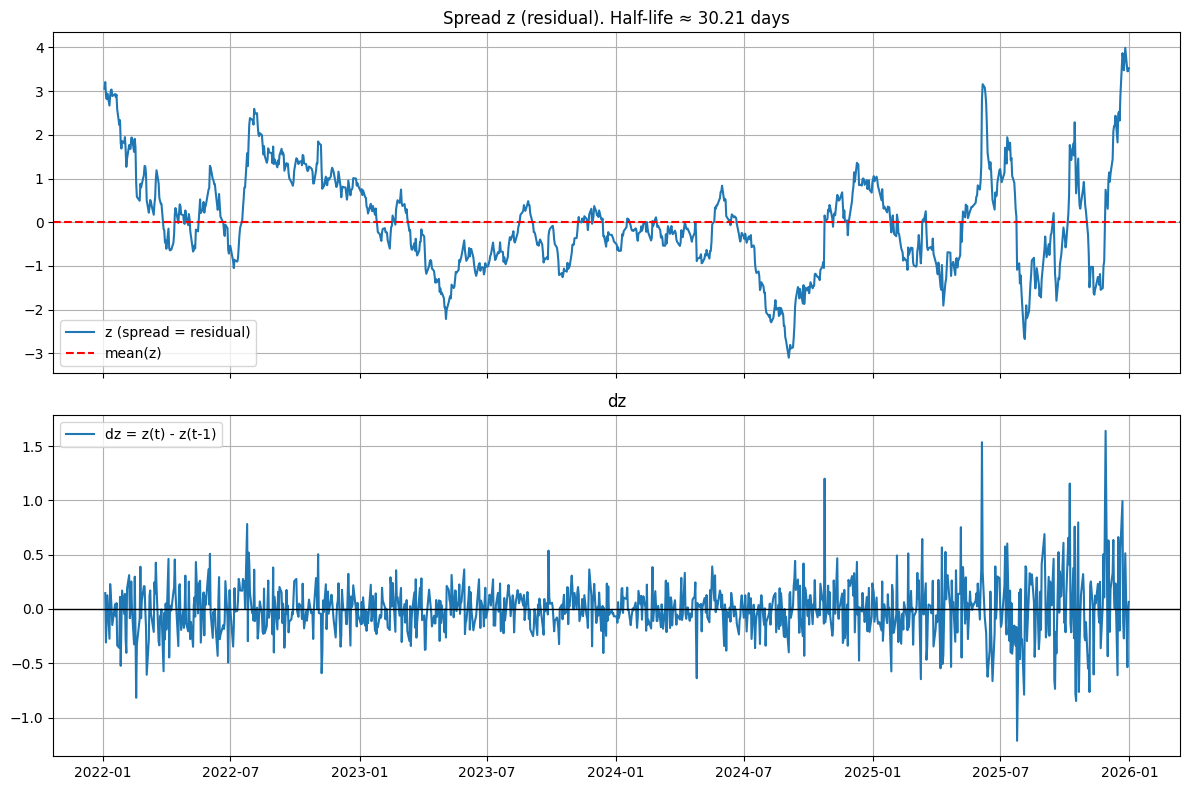

In [71]:
def analyze_pair(symbols=("GDXJ", "GDX"), start="2021-01-01", end="2026-01-01", log_price=False, add_const=True, plot=True):
    data = load_prices(list(symbols), start=start, end=end, log_price=log_price)
    y = data[symbols[0]]
    x = data[symbols[1]]

    res, beta, alpha, z = fit_spread(y, x, add_const=add_const)
    theta, halflife, dz = ou_halflife(z)
    tests = run_tests(y, x, z)

    print(f"hedge_ratio = {beta:.6f}  | alpha = {alpha:.6f}")
    print(f"theta = {theta:.6e} | half-life = {halflife:.2f} days")
    print("--- Engle-Granger ---")
    print(f"t-stat = {tests['coint_t']:.4f}, p = {tests['coint_p']:.4f} -> {tests['coint_msg']}")
    print("--- ADF on spread z ---")
    print(f"ADF stat = {tests['adf_stat']:.4f}, p = {tests['adf_p']:.4f}, lags = {tests['adf_lags']}, nobs = {tests['adf_nobs']} -> {tests['adf_msg']}")

    if plot:
        plot_spread(z, dz, halflife)

    return {
        "data": data,
        "z": z,
        "dz": dz,
        "beta": beta,
        "alpha": alpha,
        "theta": theta,
        "halflife": halflife,
        **tests,
    }

# 默认示例
pair_stats = analyze_pair(symbols=("GDXJ", "GDX"), start="2022-01-01", end="2026-01-01", log_price=False, add_const=True, plot=True)



In [72]:
def backtest_halflife_strategy(
    symbols=("GDXJ", "GDX"),
    start="2021-01-01",
    end=None,
    log_price=False,
    add_const=True,
    entry_k=2.0,
    exit_k=0.5,
    use_halflife=True,
    plot=True,
):
    """Mean-reversion backtest vs beta-neutral buy&hold using half-life as optional max hold."""
    data = load_prices(list(symbols), start=start, end=end, log_price=log_price)
    y = data[symbols[0]]
    x = data[symbols[1]]
    res, beta, alpha, z = fit_spread(y, x, add_const=add_const)

    # z-score
    zscore = (z - z.mean()) / z.std()

    # half-life (reuse helper)
    theta, halflife, dz = ou_halflife(z)
    max_hold = int(np.ceil(halflife)) if (use_halflife and np.isfinite(halflife)) else None

    # signals
    pos_y = pd.Series(0, index=z.index, dtype=float)
    pos_x = pd.Series(0, index=z.index, dtype=float)
    hold_days = 0
    regime = 0  # 1 long spread, -1 short spread, 0 flat

    for t in z.index:
        zs = zscore.loc[t]
        if regime == 0:
            if zs > entry_k:
                regime = -1
                hold_days = 0
            elif zs < -entry_k:
                regime = 1
                hold_days = 0
        else:
            hold_days += 1
            exit_cond = abs(zs) < exit_k
            time_cond = (max_hold is not None) and (hold_days >= max_hold)
            if exit_cond or time_cond:
                regime = 0
                hold_days = 0
        # set positions for today based on regime after checks
        if regime == 1:
            pos_y.loc[t] = 1
            pos_x.loc[t] = -beta
        elif regime == -1:
            pos_y.loc[t] = -1
            pos_x.loc[t] = beta
        else:
            pos_y.loc[t] = 0
            pos_x.loc[t] = 0

    # returns
    rets = data.pct_change().fillna(0)
    strat_ret = (pos_y.shift(1) * rets[symbols[0]] + pos_x.shift(1) * rets[symbols[1]]).fillna(0)

    # beta-neutral buy&hold baseline
    bh_pos_y = pd.Series(1.0, index=z.index)
    bh_pos_x = pd.Series(-beta, index=z.index)
    bh_ret = (bh_pos_y.shift(1) * rets[symbols[0]] + bh_pos_x.shift(1) * rets[symbols[1]]).fillna(0)

    strat_curve = (1 + strat_ret).cumprod()
    bh_curve = (1 + bh_ret).cumprod()

    if plot:
        plt.figure(figsize=(12,6))
        plt.plot(strat_curve, label="Half-life MR")
        plt.plot(bh_curve, label="Beta-neutral Buy&Hold", linestyle="--")
        plt.title(f"Equity curve: {symbols[0]} vs {symbols[1]} | entry={entry_k}, exit={exit_k}, max_hold={max_hold}")
        plt.grid(True)
        plt.legend()
        plt.show()

    summary = {
        "hedge_ratio": beta,
        "halflife": halflife,
        "max_hold_days": max_hold,
        "strat_return": strat_curve.iloc[-1] - 1,
        "bh_return": bh_curve.iloc[-1] - 1,
        "strat_sharpe": np.sqrt(252) * strat_ret.mean() / (strat_ret.std() + 1e-9),
        "bh_sharpe": np.sqrt(252) * bh_ret.mean() / (bh_ret.std() + 1e-9),
    }
    print("\nStrategy vs Buy&Hold")
    for k, v in summary.items():
        print(f"{k}: {v}")
    return summary


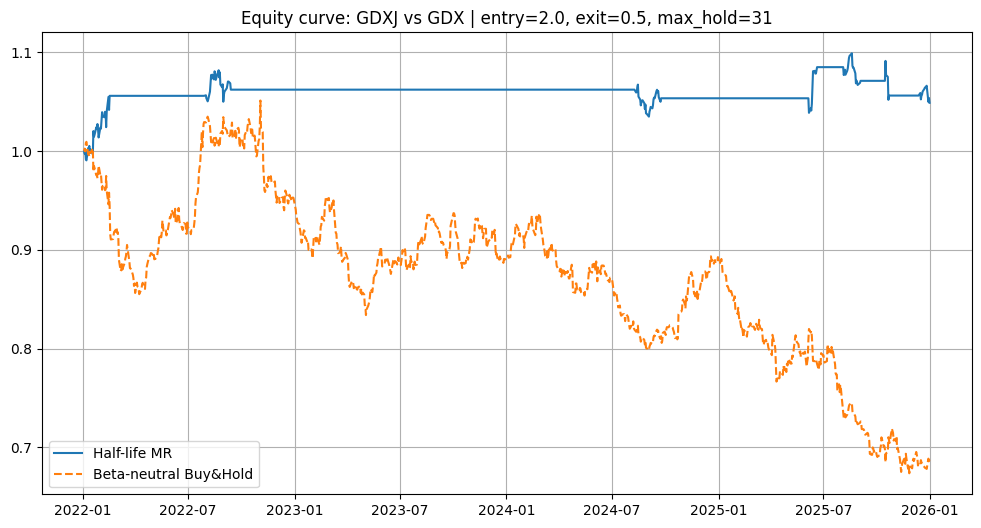


Strategy vs Buy&Hold
hedge_ratio: 1.3316088040432439
halflife: 30.20723470360188
max_hold_days: 31
strat_return: 0.048926291550551504
bh_return: -0.3109680990132976
strat_sharpe: 0.31762800738184166
bh_sharpe: -0.7584166366247808


In [73]:
# Demo: run backtest vs beta-neutral buy&hold
_ = backtest_halflife_strategy(
    symbols=("GDXJ", "GDX"),
    start="2022-01-01",
    end="2026-01-01",
    log_price=False,
    add_const=True,
    entry_k=2.0,
    exit_k=0.5,
    use_halflife=True,
    plot=True,
)


## 策略回测结果分析总结

### 1. 策略逻辑回顾

* **建模阶段**：利用全样本 OLS 估算对冲比率 ，并提取残差序列 （Spread）。
* **信号生成**：基于全样本  的均值和标准差计算 Z-Score。
* **交易执行**：
* **入场**：Z-Score （做空价差）或 （做多价差）。
* **出场**： 或 持仓时间超过半衰期（Half-life）。


* **基准 (B&H)**：长期持有价差（Buy 1单位 ，Sell 单位 ），即“长期做多价差”。

### 2. 核心现象解读：策略“躺平” vs. 基准“一路下行”

针对回测图中策略曲线（Strategy）出现长段平稳，而基准曲线（Buy & Hold）持续下跌的现象，分析如下：

#### A. 为什么策略曲线（Strategy）频繁出现“平线”？

* **空仓避险**：策略曲线的水平段并非因为价差不波动，而是因为**信号未触发**。由于策略采用全样本 Z-Score 阈值（），当后期价差波动收敛或未触及极端阈值时，策略保持空仓，收益率为 0，表现为水平线。
* **交易离散性**：策略本质是捕捉“离散的均值回归机会”。早期触发了几次交易并获利/止损后，后续因不满足入场条件而“躺平”，收益被锁定在早期水平。

#### B. 为什么基准曲线（Buy & Hold）表现极差？

* **价差结构漂移**：基准的逻辑是“永久做多价差”。如果残差  在样本后期出现趋势性下行（即  相对  持续走弱），基准就会产生持续亏损。
* **全样本静态参数风险**： 是基于全样本一次性估计的。在实际市场中，两品种的关系会随时间漂移，静态的  无法维持长期的对冲中性，导致基准曲线不仅要承受价差波动，还要承受对冲偏离带来的趋势性损失。

### 3. 结论：如何评估该策略？

* **优势**：策略通过**阈值过滤**，天然规避了基准（B&H）在价差下行阶段的持续亏损。它只在统计学意义上的“极端高/低位”入场，体现了均值回归策略的择时价值。
* **局限性**：
* **Half-life 作用受限**：由于策略大部分时间空仓，半衰期作为出场控制的作用被稀释，策略表现更多取决于入场阈值和样本标准化方式。
* **后视镜偏误**：由于使用了“全样本”的均值和标准差来计算 Z-Score，这在实盘中是不可实现的（实盘只能用 Rolling 滚动计算），这可能导致回测结果过于理想化或导致信号过于稀疏。


---

**下一步建议：**
可以尝试将 **全样本 Z-Score** 改为 **Rolling Z-Score**（滚动窗口计算），看看在动态阈值下，策略是否能捕捉到更多中后期的交易机会。